In [1]:
import sys
import os
import sys

import joblib
import pandas as pd
import numpy as np


# Add the parent directory (project root) to sys.path
sys.path.append(os.path.abspath('..'))

from src.reinforcement.reward import calculate_reward
from src.reinforcement.environment import FraudDetectionEnvironment
from src.reinforcement.agent import QLearningAgent


In [2]:
actions = {
    0: "APPROVE",
    1: "REVIEW",
    2: "BLOCK"
}

for actual_class in [0, 1]:

    print(
        "\nActual:",
        "LEGITIMATE" if actual_class == 0 else "FRAUD"
    )

    for action, action_name in actions.items():

        reward = calculate_reward(
            actual_class,
            action
        )

        print(
            f"{action_name}: {reward}"
        )


Actual: LEGITIMATE
APPROVE: 1
REVIEW: -1
BLOCK: -5

Actual: FRAUD
APPROVE: -10
REVIEW: 5
BLOCK: 10


In [3]:
df = pd.read_csv(
    "../data/processed/creditcard_processed.csv"
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (283726, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [4]:
calibrated_model = joblib.load(
    "../models/calibrated_smote_model.pkl"
)

print("Calibrated SMOTE model loaded successfully.")

Calibrated SMOTE model loaded successfully.


In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Test set:", X_test.shape)
print("Test labels:", y_test.shape)

Test set: (56746, 30)
Test labels: (56746,)


In [7]:
test_probabilities = calibrated_model.predict_proba(
    X_test
)[:, 1]

print("First 10 calibrated probabilities:")
print(test_probabilities[:10])

First 10 calibrated probabilities:
[1.51663722e-04 1.63495730e-05 1.60874317e-04 2.57843151e-05
 1.24859779e-03 3.63699941e-05 1.80407403e-05 1.91783029e-05
 2.33153564e-04 1.60019084e-05]


In [8]:
test_amounts = X_test["Amount"].to_numpy()

print("First 10 transaction amounts:")
print(test_amounts[:10])

First 10 transaction amounts:
[ 11.5    1.94  91.28 228.     1.41  20.99 234.9   21.44  20.    59.82]


In [9]:
env = FraudDetectionEnvironment(
    probabilities=test_probabilities,
    amounts=test_amounts,
    actual_labels=y_test.to_numpy(),
    alert_budget=500
)

print("Environment created successfully.")
print("Number of transactions:", env.n_transactions)
print("Initial alert budget:", env.alert_budget)

Environment created successfully.
Number of transactions: 56746
Initial alert budget: 500


In [10]:
state = env.reset()

print("Initial normalized state:")
print(state)

Initial normalized state:
[1.3364716e-04 3.7837350e-01 1.0000000e+00]


In [11]:
print("Fraud probability:", state[0])
print("Normalized amount:", state[1])
print("Normalized alert budget:", state[2])

Fraud probability: 0.00013364716
Normalized amount: 0.3783735
Normalized alert budget: 1.0


In [12]:

next_state, reward, done, info = env.step(
    FraudDetectionEnvironment.APPROVE
)

print("Next state:", next_state)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Next state: [7.7561075e-05 1.8531682e-01 1.0000000e+00]
Reward: 1
Done: False
Info: {'real_index': 41985, 'actual_class': 0, 'action': 0, 'alert_budget': 500}


In [13]:
state = env.reset()

print("Alert budget before review:", env.alert_budget)

Alert budget before review: 500


In [14]:
next_state, reward, done, info = env.step(
    FraudDetectionEnvironment.REVIEW
)

print("Reward:", reward)
print("Alert budget after review:", env.alert_budget)
print("Info:", info)

Reward: -1
Alert budget after review: 499
Info: {'real_index': 21583, 'actual_class': 0, 'action': 1, 'alert_budget': 499}


In [15]:
state = env.reset()

next_state, reward, done, info = env.step(
    FraudDetectionEnvironment.BLOCK
)

print("Reward:", reward)
print("Alert budget:", env.alert_budget)
print("Info:", info)

Reward: -5
Alert budget: 500
Info: {'real_index': 25919, 'actual_class': 0, 'action': 2, 'alert_budget': 500}


In [16]:
fraud_index = np.where(
    y_test.to_numpy() == 1
)[0][0]

print("Fraud index:", fraud_index)
print("Fraud probability:", test_probabilities[fraud_index])
print("Transaction amount:", test_amounts[fraud_index])

Fraud index: 845
Fraud probability: 0.7891761685984691
Transaction amount: 76.94


In [17]:
fraud_env = FraudDetectionEnvironment(
    probabilities=test_probabilities[
        fraud_index:fraud_index + 1
    ],
    amounts=test_amounts[
        fraud_index:fraud_index + 1
    ],
    actual_labels=y_test.to_numpy()[
        fraud_index:fraud_index + 1
    ],
    alert_budget=500
)

In [18]:
actions = {
    FraudDetectionEnvironment.APPROVE: "APPROVE",
    FraudDetectionEnvironment.REVIEW: "REVIEW",
    FraudDetectionEnvironment.BLOCK: "BLOCK"
}

for action, name in actions.items():

    fraud_env.reset()

    next_state, reward, done, info = fraud_env.step(action)

    print(
        f"{name:8s} | "
        f"Reward: {reward:3d} | "
        f"Actual: {info['actual_class']} | "
        f"Budget: {info['alert_budget']}"
    )

APPROVE  | Reward: -10 | Actual: 1 | Budget: 500
REVIEW   | Reward:   5 | Actual: 1 | Budget: 499
BLOCK    | Reward:  10 | Actual: 1 | Budget: 500


In [19]:
# test qa learning
agent = QLearningAgent(
    n_actions=3,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

print("Agent created successfully.")
print("Initial epsilon:", agent.epsilon)

Agent created successfully.
Initial epsilon: 1.0


In [20]:
state = env.reset()

q_values = agent.get_q_values(state)

print("State:")
print(state)

print("\nQ-values:")
print(q_values)

State:
[4.2208547e-05 3.6025041e-01 1.0000000e+00]

Q-values:
[0. 0. 0.]


In [21]:
action = agent.choose_action(state)

print("Selected action:", action)

Selected action: 2


In [22]:
next_state, reward, done, info = env.step(
    action
)

print("Action:", action)
print("Reward:", reward)
print("Next state:", next_state)
print("Done:", done)

Action: 2
Reward: -5
Next state: [2.5087204e-05 1.6094379e-01 1.0000000e+00]
Done: False


In [23]:
agent.update(
    state,
    action,
    reward,
    next_state,
    done
)

In [24]:
print(
    "Updated Q-values:",
    agent.get_q_values(state)
)

Updated Q-values: [ 0.   0.  -0.5]


In [25]:
train_probabilities = calibrated_model.predict_proba(
    X_train
)[:, 1]

train_amounts = X_train["Amount"].to_numpy()

train_labels = y_train.to_numpy()

print("Training transactions:", len(train_labels))
print("Training frauds:", train_labels.sum())

Training transactions: 226980
Training frauds: 378


In [29]:
train_env = FraudDetectionEnvironment(
    probabilities=train_probabilities,
    amounts=train_amounts,
    actual_labels=train_labels,
    alert_budget=500
)
print("Training environment created.")
print("Transactions:", train_env.n_transactions)
print("Initial alert budget:", train_env.alert_budget)

Training environment created.
Transactions: 226980
Initial alert budget: 500


In [31]:
state = train_env.reset(
    shuffle=True,
    episode_size=5000
)

print("Initial state:", state)
print("Episode size:", train_env.episode_size)
print("Alert budget:", train_env.alert_budget)

Initial state: [1.9930552e-04 4.3306017e-01 1.0000000e+00]
Episode size: 5000
Alert budget: 500


In [32]:
next_state, reward, done, info = train_env.step(
    FraudDetectionEnvironment.APPROVE
)

print("Next state:", next_state)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Next state: [1.8363424e-05 2.1961129e-01 1.0000000e+00]
Reward: 1
Done: False
Info: {'real_index': 124876, 'actual_class': 0, 'action': 0, 'alert_budget': 500}


In [33]:
agent = QLearningAgent(
    n_actions=3,
    learning_rate=0.1,
    discount_factor=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

print("Fresh agent created.")
print("Initial epsilon:", agent.epsilon)

Fresh agent created.
Initial epsilon: 1.0


In [34]:
n_episodes = 100
episode_size = 5000

training_history = []

for episode in range(n_episodes):

    state = train_env.reset(
        shuffle=True,
        episode_size=episode_size
    )

    total_reward = 0

    action_counts = {
        0: 0,  # APPROVE
        1: 0,  # REVIEW
        2: 0   # BLOCK
    }

    done = False

    while not done:

        action = agent.choose_action(state)

        next_state, reward, done, info = train_env.step(
            action
        )

        agent.update(
            state,
            action,
            reward,
            next_state,
            done
        )

        action_counts[action] += 1
        total_reward += reward

        state = next_state

    agent.decay_epsilon()

    training_history.append({
        "episode": episode + 1,
        "reward": total_reward,
        "approve": action_counts[0],
        "review": action_counts[1],
        "block": action_counts[2],
        "epsilon": agent.epsilon
    })

    if (episode + 1) % 10 == 0:

        print(
            f"Episode {episode + 1:3d} | "
            f"Reward: {total_reward:8d} | "
            f"Approve: {action_counts[0]:4d} | "
            f"Review: {action_counts[1]:4d} | "
            f"Block: {action_counts[2]:4d} | "
            f"Epsilon: {agent.epsilon:.4f}"
        )

Episode  10 | Reward:   -18108 | Approve: 1761 | Review: 1632 | Block: 1607 | Epsilon: 0.9511
Episode  20 | Reward:   -16120 | Approve: 1991 | Review: 1523 | Block: 1486 | Epsilon: 0.9046
Episode  30 | Reward:   -15131 | Approve: 2096 | Review: 1449 | Block: 1455 | Epsilon: 0.8604
Episode  40 | Reward:   -13600 | Approve: 2266 | Review: 1332 | Block: 1402 | Epsilon: 0.8183
Episode  50 | Reward:   -12375 | Approve: 2402 | Review: 1258 | Block: 1340 | Epsilon: 0.7783
Episode  60 | Reward:   -11653 | Approve: 2537 | Review: 1269 | Block: 1194 | Epsilon: 0.7403
Episode  70 | Reward:   -10276 | Approve: 2647 | Review: 1133 | Block: 1220 | Epsilon: 0.7041
Episode  80 | Reward:    -9683 | Approve: 2743 | Review: 1137 | Block: 1120 | Epsilon: 0.6696
Episode  90 | Reward:    -8383 | Approve: 2891 | Review: 1049 | Block: 1060 | Epsilon: 0.6369
Episode 100 | Reward:    -7803 | Approve: 2941 | Review:  990 | Block: 1069 | Epsilon: 0.6058


In [35]:
import pandas as pd

history_df = pd.DataFrame(
    training_history
)

history_df.head()

,episode,reward,approve,review,block,epsilon
0,1,-18662,1669,1630,1701,0.995000
1,2,-18715,1675,1668,1657,0.990025
2,3,-18490,1684,1613,1703,0.985075
3,4,-17892,1778,1607,1615,0.980150
4,5,-18233,1731,1631,1638,0.975249


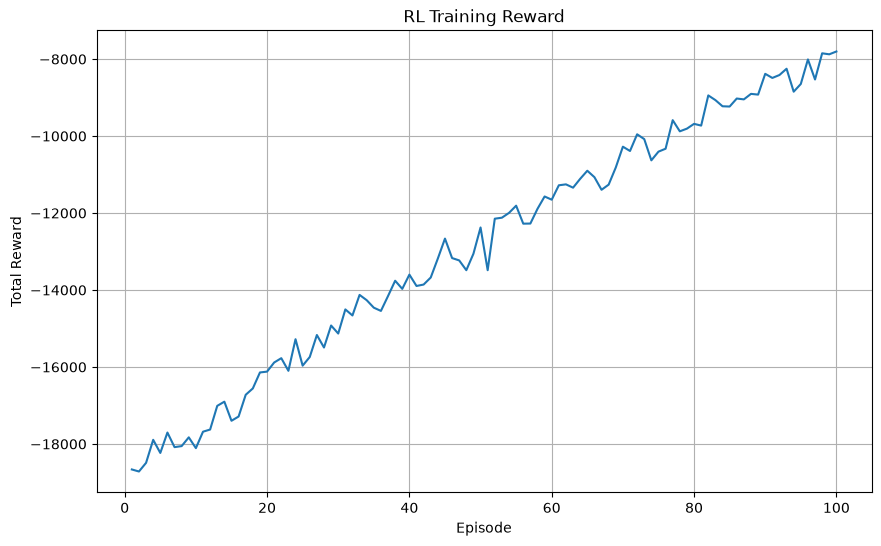

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["episode"],
    history_df["reward"]
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("RL Training Reward")

plt.grid()
plt.show()

In [37]:
history_df["reward_ma"] = (
    history_df["reward"]
    .rolling(window=10)
    .mean()
)

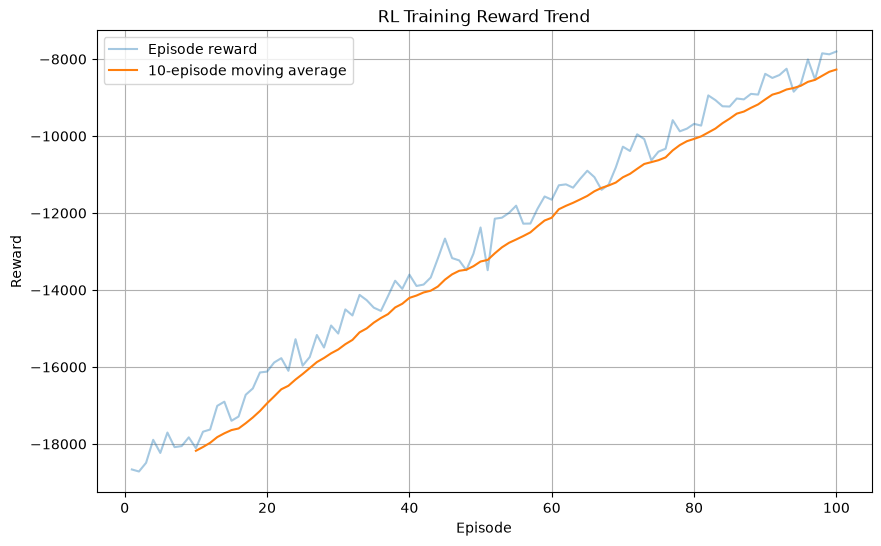

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["episode"],
    history_df["reward"],
    alpha=0.4,
    label="Episode reward"
)

plt.plot(
    history_df["episode"],
    history_df["reward_ma"],
    label="10-episode moving average"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("RL Training Reward Trend")

plt.legend()
plt.grid()

plt.show()

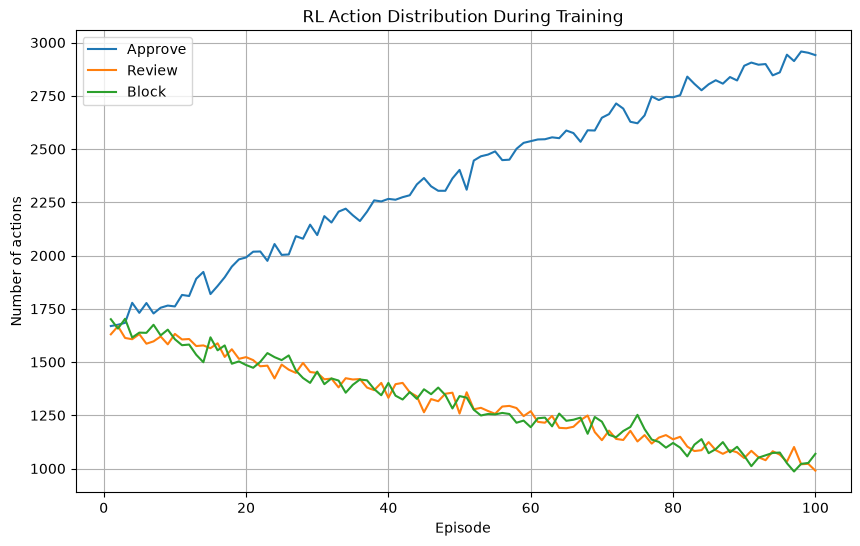

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["episode"],
    history_df["approve"],
    label="Approve"
)

plt.plot(
    history_df["episode"],
    history_df["review"],
    label="Review"
)

plt.plot(
    history_df["episode"],
    history_df["block"],
    label="Block"
)

plt.xlabel("Episode")
plt.ylabel("Number of actions")
plt.title("RL Action Distribution During Training")

plt.legend()
plt.grid()

plt.show()